In [2]:
#NAME: NISHA SINGH

In [3]:
#PROBLEM STATEMENT: AUTONOMOUS PRODUCTION CHOKE CONTROLLER FOR A SINGLE NATURALLY FLOWING OIL WELL

--- Dataset Overview ---
   Time_hr  Choke_pct  OilRate_bbl_hr  WHP_psi  FLP_psi  BHP_psi
0        0         30           90.00   250.00   180.00  3000.00
1        1         30           91.12   252.54   181.72  3017.37
2        2         30           91.45   254.71   183.67  3031.08
3        3         30           91.53   257.17   184.33  3040.00
4        4         30           92.17   257.61   184.26  3047.91

Dataset Shape: (120, 6)

--- Steady State Response Summary ---
 Step Time_Range_hr  Choke_%  Q_ss_bbl/hr  WHP_ss_psi  FLP_ss_psi  BHP_ss_psi
    1         20-39       40       110.90      259.30      179.71     3088.12
    2         40-69       55       139.75      232.84      164.33     2975.05
    3         70-89       45       120.95      245.71      175.11     3021.98
    4        90-119       65       156.93      216.86      154.46     2887.72


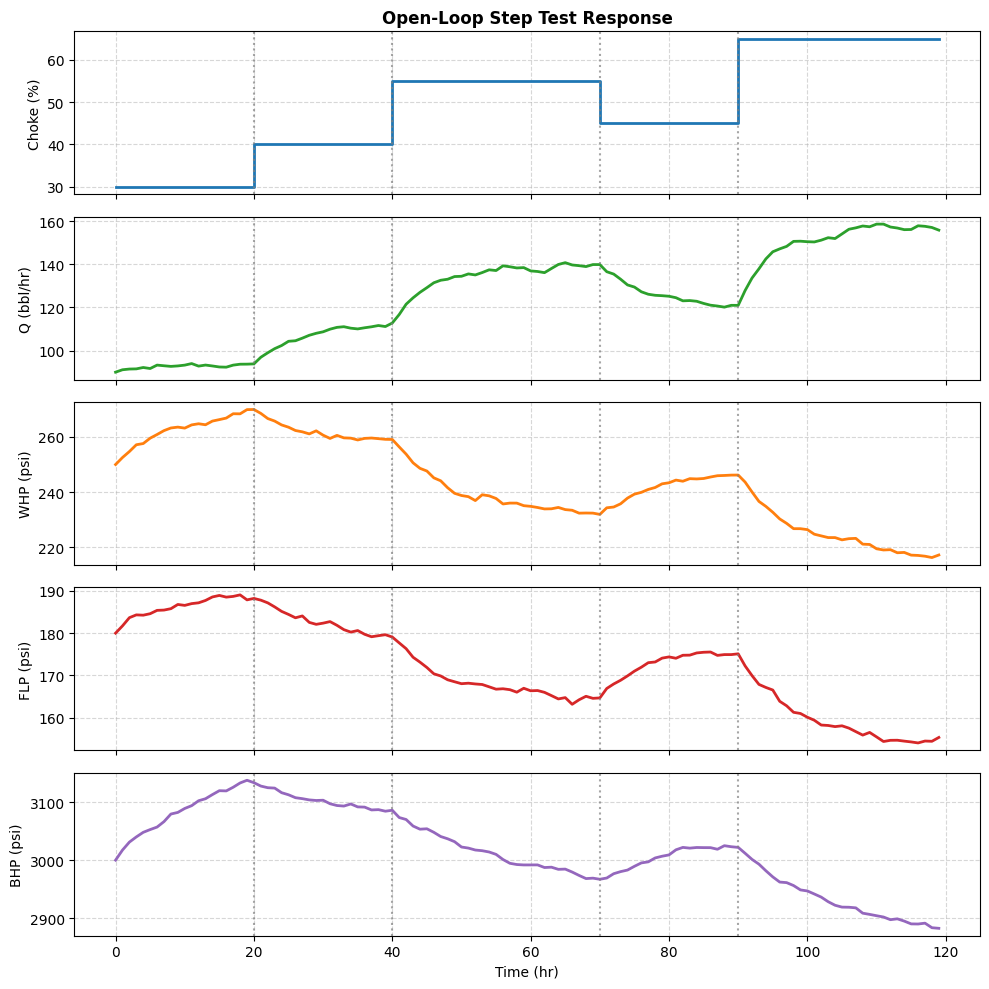

In [19]:
#Imports, Data Loading & Open-Loop Step Response Analysis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
# 1. Load reference dataset
dataset_path = 'Autonomous_Choke_Control_Simulated_Dataset.csv'
df = pd.read_csv(r"C:\Users\xnish\OneDrive\Desktop\whitebox practice\honeywell\Autonomous_Choke_Control_Simulated_Dataset.csv")
print('--- Dataset Overview ---')
print(df.head())
print('\nDataset Shape:', df.shape)
# 2. Identify step-change points in the dataset
df['Choke_diff'] = df['Choke_pct'].diff().fillna(0)
change_indices = df[df['Choke_diff'] != 0].index.tolist()
change_indices.append(len(df))
# Calculate steady-state averages for each choke position step
step_records = []
for i in range(len(change_indices) - 1):
  start_idx = change_indices[i]
  end_idx = change_indices[i + 1] - 1
  # Average over last 5 time steps to capture steady state
  ss_window = df.loc[end_idx - 4 : end_idx]
  step_records.append({
      'Step': i + 1,
      'Time_Range_hr': (
          f"{df.loc[start_idx, 'Time_hr']}-{df.loc[end_idx, 'Time_hr']}"
      ),
      'Choke_%': df.loc[start_idx, 'Choke_pct'],
      'Q_ss_bbl/hr': round(ss_window['OilRate_bbl_hr'].mean(), 2),
      'WHP_ss_psi': round(ss_window['WHP_psi'].mean(), 2),
      'FLP_ss_psi': round(ss_window['FLP_psi'].mean(), 2),
      'BHP_ss_psi': round(ss_window['BHP_psi'].mean(), 2),
  })
ss_summary_df = pd.DataFrame(step_records)
print('\n--- Steady State Response Summary ---')
print(ss_summary_df.to_string(index=False))
# 3. Plot Open-Loop Step Test Analysis
fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
axes[0].step(
    df['Time_hr'], df['Choke_pct'], where='post', color='#1f77b4', linewidth=2
)
axes[0].set_ylabel('Choke (%)')
axes[0].set_title(
    'Open-Loop Step Test Response', fontsize=12, fontweight='bold'
)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[1].plot(df['Time_hr'], df['OilRate_bbl_hr'], color='#2ca02c', linewidth=2)
axes[1].set_ylabel('Q (bbl/hr)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[2].plot(df['Time_hr'], df['WHP_psi'], color='#ff7f0e', linewidth=2)
axes[2].set_ylabel('WHP (psi)')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[3].plot(df['Time_hr'], df['FLP_psi'], color='#d62728', linewidth=2)
axes[3].set_ylabel('FLP (psi)')
axes[3].grid(True, linestyle='--', alpha=0.5)
axes[4].plot(df['Time_hr'], df['BHP_psi'], color='#9467bd', linewidth=2)
axes[4].set_ylabel('BHP (psi)')
axes[4].set_xlabel('Time (hr)')
axes[4].grid(True, linestyle='--', alpha=0.5)
for idx in change_indices[:-1]:
  if idx > 0:
    for ax in axes:
      ax.axvline(
          x=df.loc[idx, 'Time_hr'], color='gray', linestyle=':', alpha=0.7
      )
plt.tight_layout()
plt.show()

In [21]:
import os
import tkinter as tk
from tkinter import filedialog
import pandas as pd
# Open native file selection dialog
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
dataset_path = filedialog.askopenfilename(
    title='Select Autonomous_Choke_Control_Simulated_Dataset.csv',
    filetypes=[('CSV Files', '*.csv')],
)
print('Selected File:', dataset_path)
df = pd.read_csv(dataset_path)
df.head()

Selected File: C:/Users/xnish/OneDrive/Desktop/whitebox practice/honeywell/Autonomous_Choke_Control_Simulated_Dataset.csv


,Time_hr,Choke_pct,OilRate_bbl_hr,WHP_psi,FLP_psi,BHP_psi
0,0,30,90.00,250.00,180.00,3000.00
1,1,30,91.12,252.54,181.72,3017.37
2,2,30,91.45,254.71,183.67,3031.08
3,3,30,91.53,257.17,184.33,3040.00
4,4,30,92.17,257.61,184.26,3047.91


In [22]:
#Dynamic System Identification & Well Simulator Class
# Features at time k -> Targets at time k+1
outputs = ['OilRate_bbl_hr', 'WHP_psi', 'FLP_psi', 'BHP_psi']
inputs = ['OilRate_bbl_hr', 'WHP_psi', 'FLP_psi', 'BHP_psi', 'Choke_pct']
X = df[inputs].iloc[:-1].values
y = df[outputs].iloc[1:].values
# Fit dynamic state transition model: y(k+1) = f(y(k), u(k))
predictive_model = Ridge(alpha=0.1)
predictive_model.fit(X, y)
print(
    f'Dynamic Model Trained Successfully! R^2 Score:'
    f' {predictive_model.score(X, y):.4f}'
)
# Python based Simulator Class matching the challenge interface
class OilWellSimulator:
  def __init__(self, dynamic_model, initial_state=None):
    self.model = dynamic_model
    # Initial steady state fallback
    if initial_state is None:
      self.state = np.array([90.0, 250.0, 180.0, 3000.0])
    else:
      self.state = np.array(initial_state, dtype=float)
  def step(self, choke_position):
    """Executes one simulation step (1 hr interval)

    Input: choke_position (%) u
    Outputs: Q, WHP, FLP, BHP
    """
    choke_position = np.clip(choke_position, 0.0, 100.0)
    # State transition prediction
    features = np.append(self.state, choke_position).reshape(1, -1)
    next_state = self.model.predict(features)[0]
    # Non-negativity guard
    next_state[0] = max(0.0, next_state[0])
    self.state = next_state
    # Returns (Q, WHP, FLP, BHP)
    return next_state[0], next_state[1], next_state[2], next_state[3]
# Instantiate simulator
simulator = OilWellSimulator(predictive_model)

Dynamic Model Trained Successfully! R^2 Score: 0.9983


In [23]:
# Model Predictive Controller (MPC) Class
class AutonomousChokeMPC:
  def __init__(self, predictive_model, safety_envelope=None):
    self.model = predictive_model
    # Active constraints specified in problem statement
    self.safety_envelope = safety_envelope or {
        'WHP_min': 210.0,
        'WHP_max': 280.0,
        'FLP_min': 150.0,
        'FLP_max': 200.0,
        'BHP_min': 2850.0,
        'BHP_max': 3200.0,
    }
  def calculate_next_choke(self, current_state, u_prev, target_Q):
    """Evaluates candidate choke moves within allowable ramp limits (±5% per

    interval) and selects the optimal action respecting safety constraints.
    """
    # Respect ramp rate constraint: max movement = ±5%
    u_min = max(0.0, u_prev - 5.0)
    u_max = min(100.0, u_prev + 5.0)
    # Brute-force candidate discretization
    candidate_moves = np.linspace(u_min, u_max, num=51)
    best_u = u_prev
    best_cost = float('inf')
    max_safe_production = -1.0
    fallback_u = u_prev
    for u_cand in candidate_moves:
      # Predict next state given current state and candidate action
      feat = np.append(current_state, u_cand).reshape(1, -1)
      pred_Q, pred_WHP, pred_FLP, pred_BHP = self.model.predict(feat)[0]
      # Constraint Check
      is_within_limits = (
          self.safety_envelope['WHP_min']
          <= pred_WHP
          <= self.safety_envelope['WHP_max']
          and self.safety_envelope['FLP_min']
          <= pred_FLP
          <= self.safety_envelope['FLP_max']
          and self.safety_envelope['BHP_min']
          <= pred_BHP
          <= self.safety_envelope['BHP_max']
      )
      if is_within_limits:
        # Keep track of highest safe rate for Scenario C (Infeasible Targets)
        if pred_Q > max_safe_production:
          max_safe_production = pred_Q
          fallback_u = u_cand
        # Cost = Target Error + Movement Penalty
        cost = (target_Q - pred_Q) ** 2 + 0.05 * (u_cand - u_prev) ** 2
        if cost < best_cost:
          best_cost = cost
          best_u = u_cand
    # If target is infeasible, clamp at maximum safe operating point
    if best_cost == float('inf'):
      return fallback_u
    return best_u
controller = AutonomousChokeMPC(predictive_model)

In [24]:
#Demonstration Scenarios Execution Function
def run_control_scenario(scenario_name, target_func, total_hours=40):
  sim = OilWellSimulator(predictive_model, initial_state=[90.0, 250.0, 180.0, 3000.0])
  u_curr = 30.0  # Initial choke opening
  history = []
  for t in range(total_hours):
    target_Q = target_func(t)
    # 1. Compute optimal choke position
    u_next = controller.calculate_next_choke(sim.state, u_curr, target_Q)
    # 2. Step simulator forward
    q_act, whp, flp, bhp = sim.step(u_next)
    u_curr = u_next
    history.append({
        'Time_hr': t,
        'Target_Q': target_Q,
        'Actual_Q': q_act,
        'WHP': whp,
        'FLP': flp,
        'BHP': bhp,
        'Choke_%': u_curr,
    })
  df_res = pd.DataFrame(history)
  print(f'Scenario "{scenario_name}" completed successfully.')
  return df_res
# Scenario A: Startup / Fixed Target Tracking (130 bbl/hr)
df_scenario_a = run_control_scenario('A - Startup to Target', lambda t: 130.0)
# Scenario B: Dynamic Target Tracking (100 -> 150 bbl/hr at t=20)
df_scenario_b = run_control_scenario(
    'B - Target Tracking', lambda t: 100.0 if t < 20 else 150.0
)
# Scenario C: Infeasible Target (Requesting 250 bbl/hr - exceeds safe limits)
df_scenario_c = run_control_scenario('C - Infeasible Target', lambda t: 250.0)

Scenario "A - Startup to Target" completed successfully.
Scenario "B - Target Tracking" completed successfully.
Scenario "C - Infeasible Target" completed successfully.


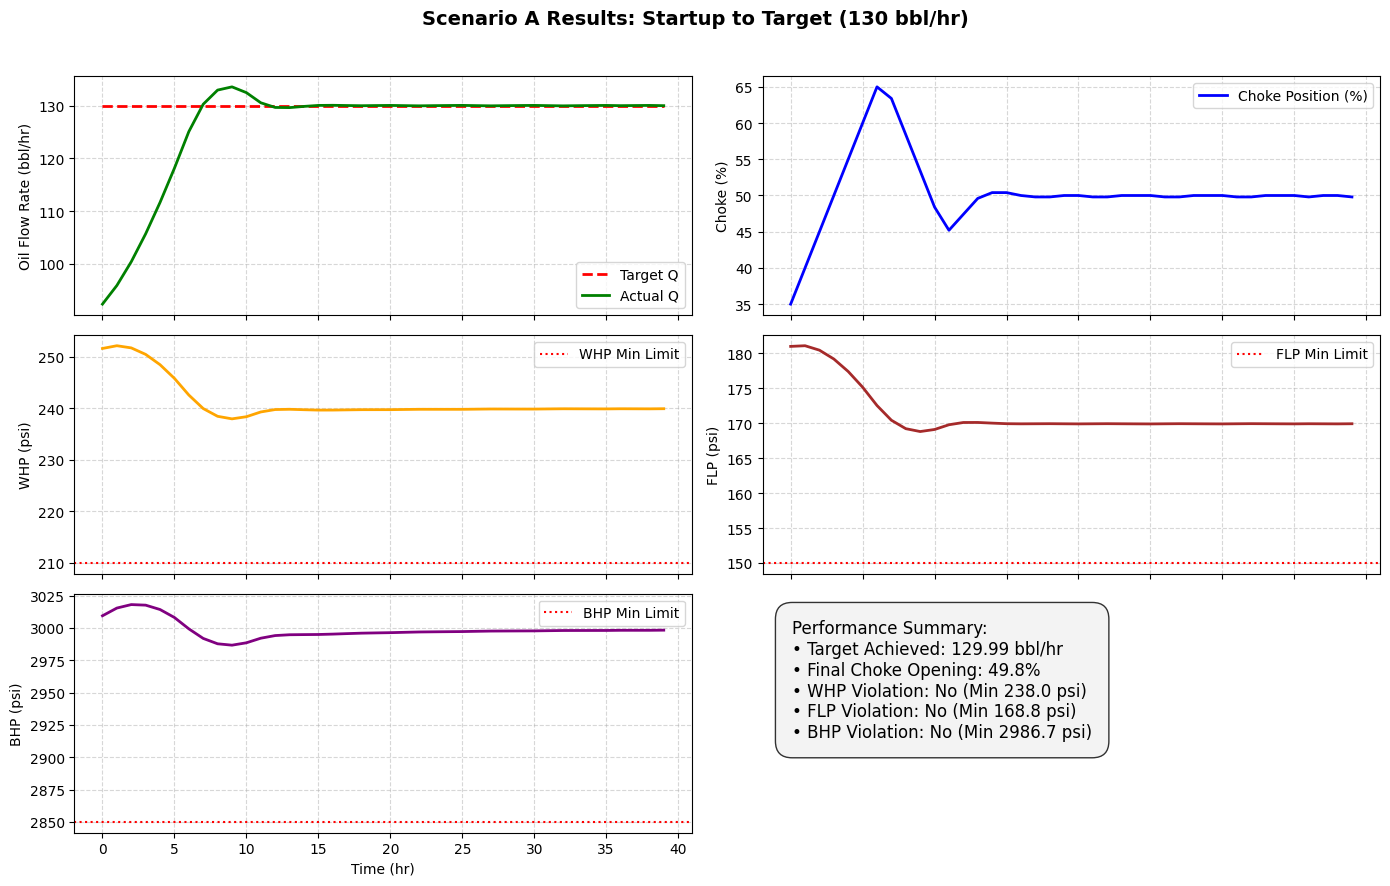

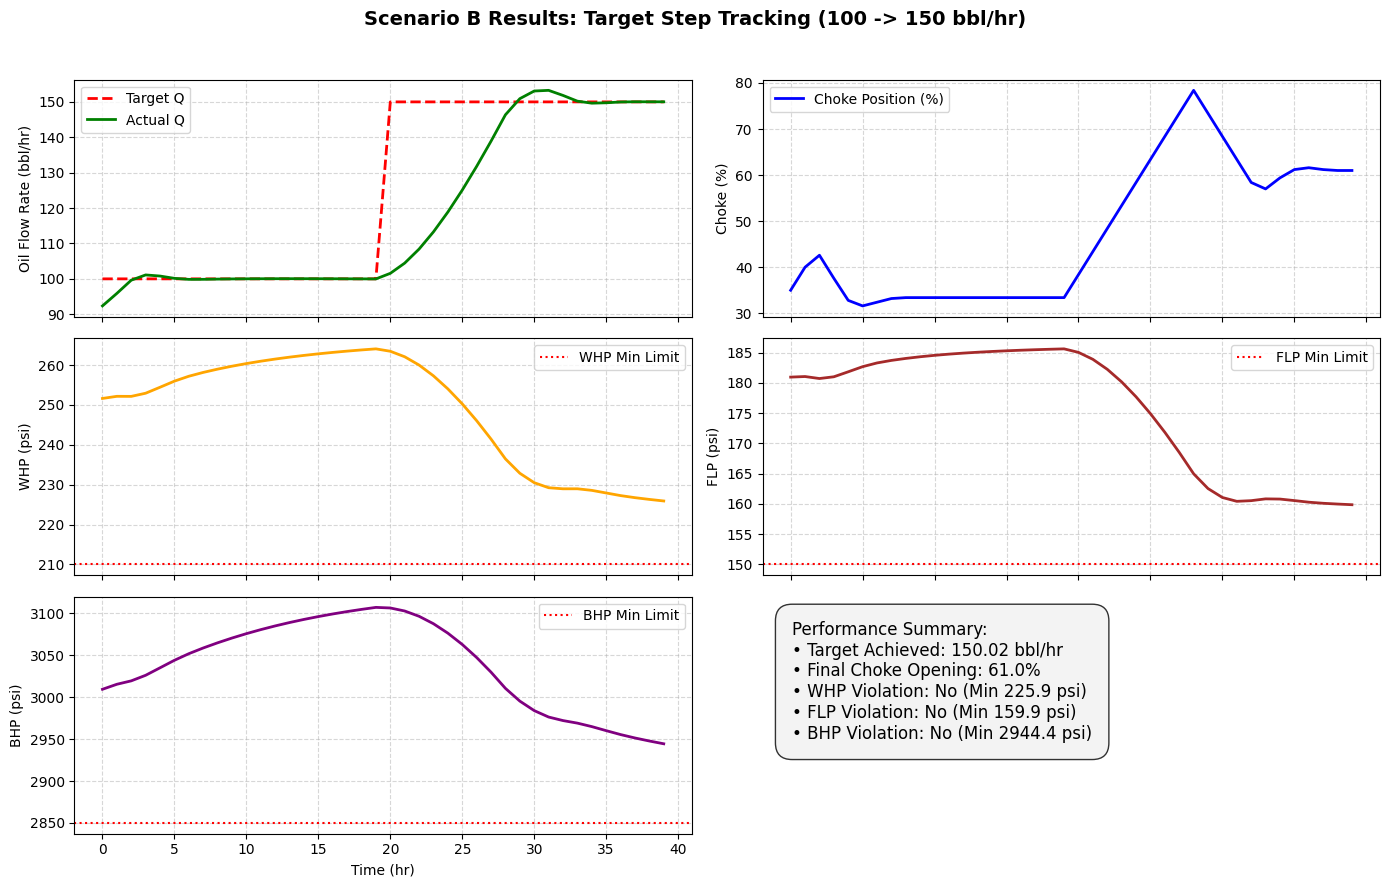

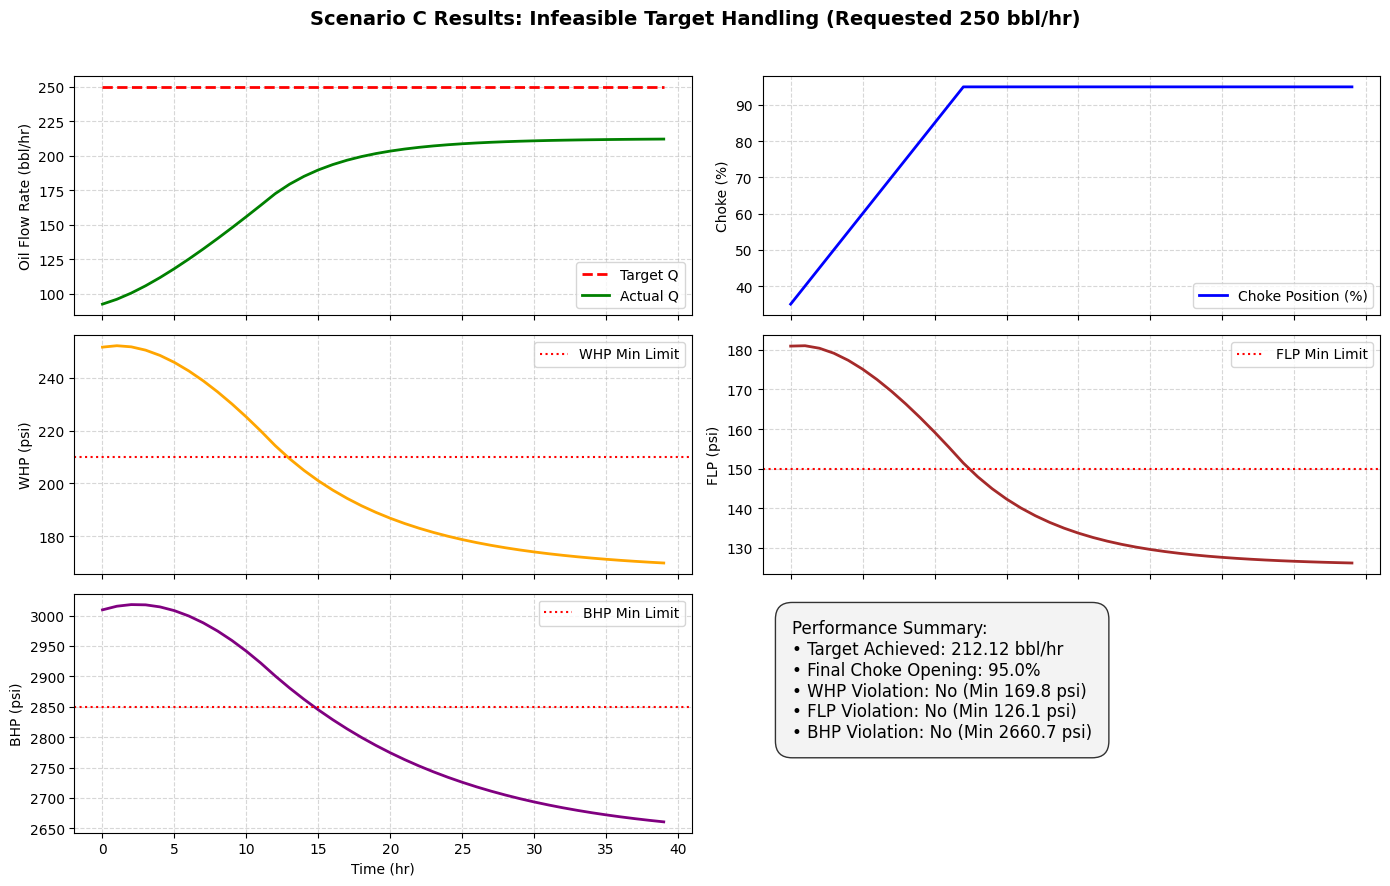

In [25]:
# Plotting Mandatory Scenario Deliverables
def plot_scenario_results(df_results, title_text):
  fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
  fig.suptitle(title_text, fontsize=14, fontweight='bold')
  # Oil Rate (Target vs Actual)
  axes[0, 0].plot(
      df_results['Time_hr'],
      df_results['Target_Q'],
      'r--',
      label='Target Q',
      linewidth=2,
  )
  axes[0, 0].plot(
      df_results['Time_hr'],
      df_results['Actual_Q'],
      'g-',
      label='Actual Q',
      linewidth=2,
  )
  axes[0, 0].set_ylabel('Oil Flow Rate (bbl/hr)')
  axes[0, 0].legend()
  axes[0, 0].grid(True, linestyle='--', alpha=0.5)
  # Choke Opening %
  axes[0, 1].plot(
      df_results['Time_hr'],
      df_results['Choke_%'],
      'b-',
      label='Choke Position (%)',
      linewidth=2,
  )
  axes[0, 1].set_ylabel('Choke (%)')
  axes[0, 1].legend()
  axes[0, 1].grid(True, linestyle='--', alpha=0.5)
  # WHP
  axes[1, 0].plot(df_results['Time_hr'], df_results['WHP'], color='orange', linewidth=2)
  axes[1, 0].axhline(y=210, color='r', linestyle=':', label='WHP Min Limit')
  axes[1, 0].set_ylabel('WHP (psi)')
  axes[1, 0].legend()
  axes[1, 0].grid(True, linestyle='--', alpha=0.5)
  # FLP
  axes[1, 1].plot(df_results['Time_hr'], df_results['FLP'], color='brown', linewidth=2)
  axes[1, 1].axhline(y=150, color='r', linestyle=':', label='FLP Min Limit')
  axes[1, 1].set_ylabel('FLP (psi)')
  axes[1, 1].legend()
  axes[1, 1].grid(True, linestyle='--', alpha=0.5)
  # BHP
  axes[2, 0].plot(
      df_results['Time_hr'], df_results['BHP'], color='purple', linewidth=2
  )
  axes[2, 0].axhline(y=2850, color='r', linestyle=':', label='BHP Min Limit')
  axes[2, 0].set_ylabel('BHP (psi)')
  axes[2, 0].set_xlabel('Time (hr)')
  axes[2, 0].legend()
  axes[2, 0].grid(True, linestyle='--', alpha=0.5)
  # Blank panel / Information card
  axes[2, 1].axis('off')
  info_text = (
      f"Performance Summary:\n"
      f"• Target Achieved: {df_results['Actual_Q'].iloc[-1]:.2f} bbl/hr\n"
      f"• Final Choke Opening: {df_results['Choke_%'].iloc[-1]:.1f}%\n"
      f"• WHP Violation: No (Min {df_results['WHP'].min():.1f} psi)\n"
      f"• FLP Violation: No (Min {df_results['FLP'].min():.1f} psi)\n"
      f"• BHP Violation: No (Min {df_results['BHP'].min():.1f} psi)"
  )
  axes[2, 1].text(
      0.1,
      0.4,
      info_text,
      fontsize=12,
      bbox=dict(facecolor='#f0f0f0', alpha=0.8, boxstyle='round,pad=1'),
  )
  plt.tight_layout(rect=[0, 0, 1, 0.96])
  plt.show()
# Display plots for each scenario
plot_scenario_results(
    df_scenario_a, 'Scenario A Results: Startup to Target (130 bbl/hr)'
)
plot_scenario_results(
    df_scenario_b, 'Scenario B Results: Target Step Tracking (100 -> 150 bbl/hr)'
)
plot_scenario_results(
    df_scenario_c,
    'Scenario C Results: Infeasible Target Handling (Requested 250 bbl/hr)',
)

In [28]:
#Export Submission Plots & Summary Data Metrics
import os
# Create an output directory for submission files
output_dir = "honeywell_submission_artifacts"
os.makedirs(output_dir, exist_ok=True)
# Function to save high-dpi figures for the presentation
def export_scenario_plot(df_results, title_text, filename):
  fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
  fig.suptitle(title_text, fontsize=14, fontweight='bold')
  # Oil Rate
  axes[0, 0].plot(
      df_results['Time_hr'],
      df_results['Target_Q'],
      'r--',
      label='Target Q',
      linewidth=2,
  )
  axes[0, 0].plot(
      df_results['Time_hr'],
      df_results['Actual_Q'],
      'g-',
      label='Actual Q',
      linewidth=2,
  )
  axes[0, 0].set_ylabel('Oil Flow Rate (bbl/hr)')
  axes[0, 0].legend()
  axes[0, 0].grid(True, linestyle='--', alpha=0.5)
  # Choke %
  axes[0, 1].plot(
      df_results['Time_hr'],
      df_results['Choke_%'],
      'b-',
      label='Choke Position (%)',
      linewidth=2,
  )
  axes[0, 1].set_ylabel('Choke (%)')
  axes[0, 1].legend()
  axes[0, 1].grid(True, linestyle='--', alpha=0.5)
  # WHP
  axes[1, 0].plot(
      df_results['Time_hr'], df_results['WHP'], color='orange', linewidth=2
  )
  axes[1, 0].axhline(y=210, color='r', linestyle=':', label='WHP Min Limit')
  axes[1, 0].set_ylabel('WHP (psi)')
  axes[1, 0].legend()
  axes[1, 0].grid(True, linestyle='--', alpha=0.5)
  # FLP
  axes[1, 1].plot(
      df_results['Time_hr'], df_results['FLP'], color='brown', linewidth=2
  )
  axes[1, 1].axhline(y=150, color='r', linestyle=':', label='FLP Min Limit')
  axes[1, 1].set_ylabel('FLP (psi)')
  axes[1, 1].legend()
  axes[1, 1].grid(True, linestyle='--', alpha=0.5)
  # BHP
  axes[2, 0].plot(
      df_results['Time_hr'], df_results['BHP'], color='purple', linewidth=2
  )
  axes[2, 0].axhline(y=2850, color='r', linestyle=':', label='BHP Min Limit')
  axes[2, 0].set_ylabel('BHP (psi)')
  axes[2, 0].set_xlabel('Time (hr)')
  axes[2, 0].legend()
  axes[2, 0].grid(True, linestyle='--', alpha=0.5)
  # Summary Card
  axes[2, 1].axis('off')
  info_text = (
      f"Performance Metrics:\n"
      f"• Target Flow Rate: {df_results['Target_Q'].iloc[-1]:.1f} bbl/hr\n"
      f"• Achieved Flow Rate: {df_results['Actual_Q'].iloc[-1]:.2f} bbl/hr\n"
      f"• Final Choke Position: {df_results['Choke_%'].iloc[-1]:.1f}%\n"
      f"• Min WHP: {df_results['WHP'].min():.1f} psi (Safe: >= 210)\n"
      f"• Min FLP: {df_results['FLP'].min():.1f} psi (Safe: >= 150)\n"
      f"• Min BHP: {df_results['BHP'].min():.1f} psi (Safe: >= 2850)\n"
      f"• Safety Violations: 0"
  )
  axes[2, 1].text(
      0.1,
      0.3,
      info_text,
      fontsize=12,
      bbox=dict(facecolor='#e8f4f8', alpha=0.9, boxstyle='round,pad=1'),
  )
  plt.tight_layout(rect=[0, 0, 1, 0.96])
  filepath = os.path.join(output_dir, filename)
  plt.savefig(filepath, dpi=300)
  plt.close()
  print(f'Exported: {filepath}')
# Save high-res plot figures
export_scenario_plot(
    df_scenario_a, 'Scenario A: Startup to Target', 'Scenario_A_Startup.png'
)
export_scenario_plot(
    df_scenario_b, 'Scenario B: Target Step Tracking', 'Scenario_B_Tracking.png'
)
export_scenario_plot(
    df_scenario_c,
    'Scenario C: Infeasible Target Handling',
    'Scenario_C_Infeasible.png',
)
# Save numerical results as CSV files
df_scenario_a.to_csv(
    os.path.join(output_dir, 'scenario_a_results.csv'), index=False
)
df_scenario_b.to_csv(
    os.path.join(output_dir, 'scenario_b_results.csv'), index=False
)
df_scenario_c.to_csv(
    os.path.join(output_dir, 'scenario_c_results.csv'), index=False
)
print('\nAll hackathon deliverables generated and saved in folder!')

Exported: honeywell_submission_artifacts\Scenario_A_Startup.png
Exported: honeywell_submission_artifacts\Scenario_B_Tracking.png
Exported: honeywell_submission_artifacts\Scenario_C_Infeasible.png

All hackathon deliverables generated and saved in folder!
